# Part 2 — molecule-head prediction metrics (`grid_0000`, plain balanced BCE)

Evaluates the molecule classification head's actual predictive quality on its held-out
test split, for all 5 repetitions of `grid_0000` (`balanced_bce`, no contractive/
contrastive terms — see `../report/methodology.md` §5). Scope for this pass, matching
`part_1`: **`grid_0000` only** — the other six objectives are a later, separate
comparison against this one.

**Why this needs its own careful metrics, not just accuracy**: the head predicts 508
molecule/adduct classes per pixel, and a typical pixel has only a handful of them
present (§2 of the methodology doc: `annotated_fraction=1.0` only guarantees ≥1
positive class per pixel, not per-class balance). A model that predicts **all zeros**
would still score a deceptively high accuracy/precision/hamming-loss on most classes,
simply because "absent" is the overwhelming majority label everywhere. This notebook
makes that trap explicit by computing the same metrics for an actual all-zero baseline
and comparing them side by side against the trained model.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import (
    evaluate_head,
    per_class_metrics,
    probabilities_from_logits,
)
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-27 23:50:51,289 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 23:50:51,292 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-27 23:50:51,943 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-27 23:50:51,944 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-27 23:50:51,946 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-27 23:50:51,947 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 23:50:51,962 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-27 23:50:52,160 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-27 23:50:52,162 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config


In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
MODEL_NAMES = [f"{CAMPAIGN_ID}__grid_0000__rep_0{repetition}" for repetition in range(5)]
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

theme = resolve_theme(None)
theme.apply()


## Environment workaround — entropy-trained `config.json` bakes in scratch paths

Every predictive-campaign model's saved `config.json` records its annotation store at
an **absolute SLURM scratch path**
(`/tmp/<remote-user>/msi-wrapper/predictive-20260824-04/kidney_workspace/datasets/kidney/kidney.sqlite`)
— the compute node's local `/tmp`, already cleaned up (see `part_0`'s notes on
`result.model_path`). Unlike the spectral reader (which resolves relative to the
workspace's own image registry and loaded successfully regardless), the annotation
reader (`MergedAnnotationReader`) trusts this stored absolute path with no fallback and
raises if it is missing.

This recreates that expected path locally as a symlink to the real, already-present
local copy — a pure filesystem workaround (no code changed) so
`wrapper.load_configuration()` can restore the full pipeline (reader, annotation
reader, binner, dataset, model) exactly as saved. Safe to re-run; `ln -sfn` overwrites
the same link idempotently.


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())
print(f"{SCRATCH_WORKSPACE_ROOT} -> {SCRATCH_WORKSPACE_ROOT.resolve()}")


/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace -> /home/max/repositories/MSIAutoEncoderWrapper/data/kidney_workspace


## Load one model + its test split, run inference

`dataset.create_partitions()` replays the exact `predefined` train/validation/test
spectrum-id assignments baked into the saved `config.json` (verified: `len(test) ==
4023`, matching the assignments recorded at training time) — this is the same held-out
population the trainer itself never optimized against, restricted the same way for
every repetition since all `grid_0000` runs share one split seed.


In [4]:
# All 5 repetitions share one image/binner/annotation-store/dataset context — only
# the model weights differ between them. `load_configuration` unconditionally
# re-resolves the raw imzML reader and annotation index on every call (measured
# ~38-40s), even when nothing about the image changed. `models_manager.load_model`
# swaps only the model architecture/weights (its own docstring: "does not require
# loading its original image") and leaves `active_dataset`/context untouched
# (measured ~0.04s) — pay the full context cost exactly once, then use the
# lightweight swap for the remaining 4 repetitions.
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=MODEL_NAMES[0])
shared_test_dataset = wrapper.active_dataset.create_partitions().test


def evaluate_test_split(model_name: str, *, first: bool) -> dict:
    model = (
        wrapper.active_model
        if first
        else wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
    )
    model.eval()
    device = next(model.parameters()).device

    logits_batches, target_batches, mask_batches = [], [], []
    loader = DataLoader(shared_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for _, spectra, targets, masks in loader:
            outputs = model(spectra.float().to(device))
            logits_batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
            target_batches.append(targets[TARGET_FIELD].numpy())
            mask_batches.append(masks[TARGET_FIELD].numpy())
    return {
        "logits": np.concatenate(logits_batches, axis=0),
        "targets": np.concatenate(target_batches, axis=0),
        "mask": np.concatenate(mask_batches, axis=0),
        "test_size": len(shared_test_dataset),
    }


results = {
    model_name: evaluate_test_split(model_name, first=(index == 0))
    for index, model_name in enumerate(MODEL_NAMES)
}
{name: result["test_size"] for name, result in results.items()}

2026-08-27 23:50:52,686 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-27 23:50:52,687 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-27 23:50:52,688 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-27 23:50:52,689 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 23:50:52,690 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-27 23:52:05,760 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 23:52:05,761 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 23:52:05,764 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 23:52:05,768 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


{'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_01': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_02': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_03': 4023,
 'kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_04': 4023}

In [5]:
# Molecule classes are scored under `unobserved_label_policy: unlabelled`: a class
# can have plenty of *available* (labelled) train pixels while every single one is a
# confirmed negative, so the model received zero positive supervision for it and had
# no way to learn to predict it. But "trainable" alone is not a fair evaluation scope
# either: a trainable class with zero positives in the split being SCORED is exactly
# as degenerate (f1/precision/recall trivially 0) as an untrainable one. The fair
# scope is always the intersection -- trainable AND scoreable-here -- computed fresh
# per split below, alongside the full-508 scope for reference.
def collect_targets_and_mask(dataset) -> tuple[np.ndarray, np.ndarray]:
    target_batches, mask_batches = [], []
    for _, _, targets, masks in DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False):
        target_batches.append(targets[TARGET_FIELD].numpy())
        mask_batches.append(masks[TARGET_FIELD].numpy())
    return np.concatenate(target_batches, axis=0), np.concatenate(mask_batches, axis=0)


train_targets_only, train_mask_only = collect_targets_and_mask(wrapper.active_dataset.create_partitions().train)
train_positive_count_per_class = (train_targets_only * train_mask_only).sum(axis=0)
train_active_class_mask = train_positive_count_per_class > 0
print(
    f"{int(train_active_class_mask.sum())}/{train_active_class_mask.shape[0]} classes had at least one "
    "positive TRAIN pixel -- only these could plausibly have been learned."
)

204/508 classes had at least one positive TRAIN pixel -- only these could plausibly have been learned.


## Class sparsity — how many positive pixels does each of the 508 classes have

### Methodology
#### Theoretical
- The introduction warns that most classes are rare per pixel; this section makes
  that concrete by counting, per class, how many test pixels are actually positive
  for it. This number directly determines whether a per-class metric (AUPRC, F1) is
  even meaningfully computable for that class, and sets up the "class coverage"
  columns used throughout the rest of this notebook.

#### Implementation
- `positive_samples` per class, pooled from `per_class_metrics` on `reference_result`
  (rep 0, test split) — the count of test pixels where that class is both available
  (labelled) and positive. Plotted as a histogram over all 508 classes.

### Notes
- 508 molecule classes total; 395/508 have ZERO positive test pixels. Median
  positive pixels/class: 0; mean: 230.9; max: 2720 — the distribution is extremely
  right-skewed, dominated by a small number of common classes.
- 304/508 classes also had ZERO positive TRAIN pixels — never learnable by this
  model at all (see the next section for why this matters for evaluation scope).


In [6]:
reference_result = results[MODEL_NAMES[0]]
reference_probabilities = probabilities_from_logits(reference_result["logits"], "multi_label")
reference_class_metrics = pd.DataFrame(
    per_class_metrics(reference_probabilities, reference_result["targets"], THRESHOLD, reference_result["mask"])
)

class_count = reference_result["targets"].shape[1]
zero_positive_classes = int((reference_class_metrics["positive_samples"] == 0).sum())
print(f"{class_count} molecule classes total")
print(f"{zero_positive_classes}/{class_count} classes have ZERO positive test pixels")
print(
    f"median positive pixels/class: {reference_class_metrics['positive_samples'].median():.0f}, "
    f"mean: {reference_class_metrics['positive_samples'].mean():.1f}, "
    f"max: {reference_class_metrics['positive_samples'].max():.0f}"
)
print(f"{int((~train_active_class_mask).sum())}/{class_count} classes had ZERO positive TRAIN pixels (never learnable, see next cell)")


508 molecule classes total
395/508 classes have ZERO positive test pixels
median positive pixels/class: 0, mean: 230.9, max: 2720
304/508 classes had ZERO positive TRAIN pixels (never learnable, see next cell)


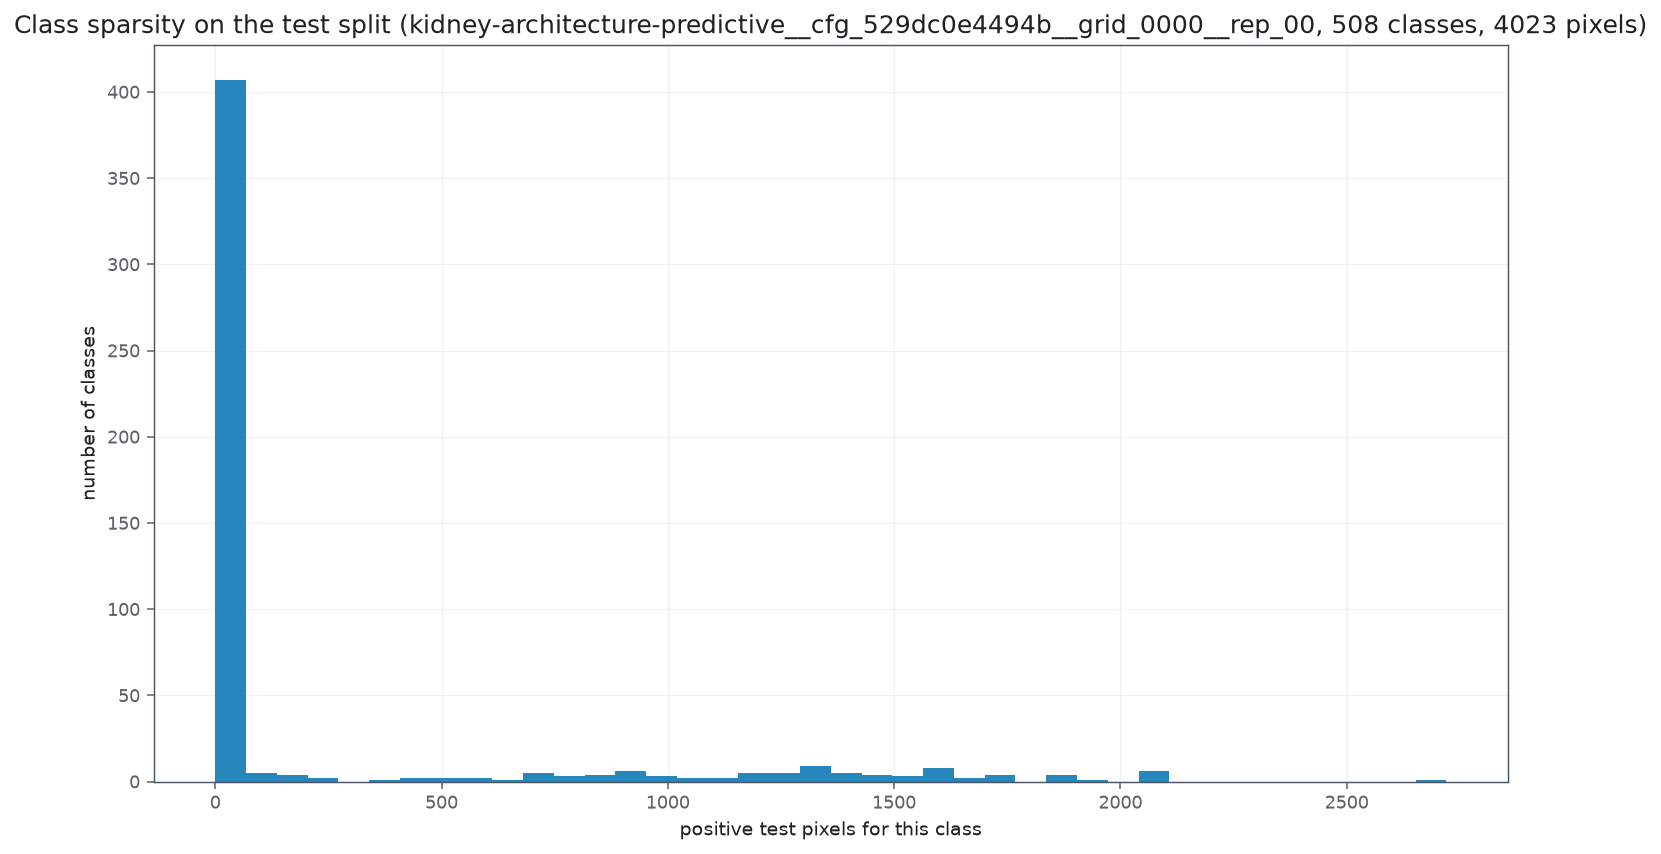

In [7]:
import matplotlib.pyplot as plt

figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
ax.hist(
    reference_class_metrics["positive_samples"],
    bins=40,
    color=theme.color_for_model("positive_samples", 0),
    alpha=theme.primary_alpha,
)
ax.set(
    xlabel="positive test pixels for this class",
    ylabel="number of classes",
    title=f"Class sparsity on the test split ({MODEL_NAMES[0]}, {class_count} classes, {reference_result['test_size']} pixels)",
)
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()


## Generalization gap — train vs. validation vs. test, by class-learnability scope

### Methodology
#### Theoretical
- Every metric elsewhere in this notebook is computed on `test` only. Here the same
  `evaluate_head` metrics are computed on the pixels the model actually trained on
  (`train`) and the pixels used for checkpoint selection but never trained on
  directly (`validation`), for repetition 0 — matching `part_6`'s convention (all 5
  repetitions on `test`, one repetition additionally on `train`/`validation`) for a
  direct generalization-gap read.
- A class being *learnable* (had ≥1 positive train pixel) does not make it *fairly
  scoreable* in a given split — a learnable class with zero positives in the split
  being scored is exactly as degenerate (f1/precision/recall trivially 0) as an
  unlearnable one. So every metric below is reported in two scopes side by side: the
  full 508-class pool, and the intersection of train-active with that split's own
  active classes (`train-active ∩ split-active`) — the fair scope, since it isolates
  classes the model could have learned *and* that actually have ground truth to score
  against in that split.

#### Implementation
- `evaluate_split(model, dataset)` runs the model over a split and collects
  logits/targets/mask, same as the main test-split loader. For each split, class
  coverage (`active_classes`, `zero_classes`) is computed directly from
  `(targets * mask).sum(axis=0) > 0` — no model inference needed for that part. The
  fair-scope mask is `train_active_class_mask & split_active_mask`, recomputed per
  split (it is *not* a single fixed set — validation's and test's fair scopes are
  different, smaller intersections). `evaluate_head` is then called twice per split,
  once with `class_selector = slice(None)` (all classes) and once with the fair
  mask, both on the same `logits`/`targets`/`mask` arrays sliced along the class
  axis. Results are assembled into a grouped table (`class coverage` | `all classes
  (508)` | `train-active ∩ split-active`, each further split into ranking/macro/
  micro/calibration metric families) and an equivalent bar chart, one bar-group row
  per scope.

### Notes


In [8]:
def evaluate_split(model, dataset) -> dict:
    device = next(model.parameters()).device
    logits_batches, target_batches, mask_batches = [], [], []
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for _, spectra, targets, masks in loader:
            outputs = model(spectra.float().to(device))
            logits_batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
            target_batches.append(targets[TARGET_FIELD].numpy())
            mask_batches.append(masks[TARGET_FIELD].numpy())
    return {
        "logits": np.concatenate(logits_batches, axis=0),
        "targets": np.concatenate(target_batches, axis=0),
        "mask": np.concatenate(mask_batches, axis=0),
        "size": len(dataset),
    }


# Re-load rep_0 explicitly rather than trusting wrapper.active_model — the loop above
# left it pointing at whichever repetition was loaded last (rep_4), since
# `models_manager.load_model` updates the wrapper's active model as a side effect.
# `active_dataset`/context are untouched by any of this (same context every repetition),
# so `create_partitions()` here still returns the correct, shared train/validation split.
rep0_model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=MODEL_NAMES[0], strict=True)
rep0_model.eval()
rep0_partitions = wrapper.active_dataset.create_partitions()

gap_results = {
    "train": evaluate_split(rep0_model, rep0_partitions.train),
    "validation": evaluate_split(rep0_model, rep0_partitions.validation),
    "test": results[MODEL_NAMES[0]],
}

# Two tracks, everywhere downstream: the full 508-class scope (comparable to earlier
# passes) and the fair scope -- train-active AND active in the split being scored.
# The fair scope's actual class set differs per split (train's fair set is just
# train-active itself; validation's/test's are the intersection with their own
# nonzero classes) but shares one label, so it lines up as a single column group.
ALL_CLASSES_SCOPE = "all classes (508)"
TRAIN_ACTIVE_SCOPE = "train-active ∩ split-active"

coverage_rows = []
gap_rows = []
for split_name, result in gap_results.items():
    positive_count_per_class = (result["targets"] * result["mask"]).sum(axis=0)
    split_active_mask = positive_count_per_class > 0
    active_classes = int(split_active_mask.sum())
    fair_mask = train_active_class_mask & split_active_mask
    coverage_rows.append({
        "split": split_name,
        "size": result.get("size", result.get("test_size")),
        "active_classes": active_classes,
        "zero_classes": positive_count_per_class.shape[0] - active_classes,
        "train_active_and_split_active": int(fair_mask.sum()),
    })
    for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (TRAIN_ACTIVE_SCOPE, fair_mask)):
        metrics = evaluate_head(
            result["logits"][:, class_selector], result["targets"][:, class_selector],
            "multi_label", result["mask"][:, class_selector], THRESHOLD,
        )
        gap_rows.append({"split": split_name, "scope": scope_name, **metrics})

coverage_frame = pd.DataFrame(coverage_rows).set_index("split")
gap_frame = pd.DataFrame(gap_rows)  # long form: one row per (split, scope)
gap_by_split_scope = gap_frame.set_index(["split", "scope"])

# Every metric evaluate_head returns, grouped so the table is scannable rather than a
# flat wall of columns: non-thresholded ranking metrics first (the ones actually
# trusted), then macro/micro/calibration for context.
METRIC_GROUPS = {
    "ranking (threshold-free)": ["average_precision", "roc_auc"],
    "macro": ["macro_f1"],
    "micro": ["micro_f1", "micro_precision", "micro_recall"],
    "calibration @ 0.5": ["hamming_loss", "hamming_loss_baseline_positive_rate"],
}
coverage_frame.columns = pd.MultiIndex.from_tuples(
    [("class coverage", "", column) for column in coverage_frame.columns]
)
scope_column_tuples = [
    (scope_name, group, column)
    for scope_name in (ALL_CLASSES_SCOPE, TRAIN_ACTIVE_SCOPE)
    for group, columns in METRIC_GROUPS.items()
    for column in columns
]
scoped_metrics_frame = pd.DataFrame(
    {
        column_tuple: gap_by_split_scope.xs(column_tuple[0], level="scope")[column_tuple[2]]
        for column_tuple in scope_column_tuples
    },
    index=coverage_frame.index,
)
scoped_metrics_frame.columns = pd.MultiIndex.from_tuples(scope_column_tuples)

grouped_gap_frame = pd.concat([coverage_frame, scoped_metrics_frame], axis=1)
grouped_gap_frame

2026-08-27 23:52:55,048 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 23:52:55,048 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-08-27 23:52:55,049 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-08-27 23:52:55,050 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-08-27 23:52:55,056 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-08-27 23:52:55,061 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 23:52:55,061 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 23:52:55,064 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 23:52:55,072 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


class coverage                              \
                                                        
                     size active_classes zero_classes   
split                                                   
train               33553            204          304   
validation           4488            319          189   
test                 4023            113          395   

                                                all classes (508)            \
                                         ranking (threshold-free)             
           train_active_and_split_active        average_precision   roc_auc   
split                                                                         
train                                204                 0.613690  0.979513   
validation                            68                 0.203783  0.544563   
test                                  31                 0.385860  0.576276   

                                                                               \
               macro     micro                              calibration @ 0.5   
            macro_f1  micro_f1 micro_precision micro_recall      hamming_loss   
split                                                                           
train       0.232623  0.208419        0.116507     0.987307          0.327261   
validation  0.094898  0.210680        0.133094     0.505152          0.316444   
test        0.051750  0.129376        0.076493     0.419160          0.323778   

                                               train-active ∩ split-active  \
                                                  ranking (threshold-free)   
           hamming_loss_baseline_positive_rate           average_precision   
split                                                                        
train                                 0.043637                    0.613690   
validation                            0.083602                    0.310236   
test                                  0.057393                    0.599645   

                                                                       \
                         macro     micro                                
             roc_auc  macro_f1  micro_f1 micro_precision micro_recall   
split                                                                   
train       0.979513  0.579276  0.811944        0.689480     0.987307   
validation  0.739630  0.122375  0.313979        0.436999     0.245007   
test        0.805667  0.143593  0.216229        0.586916     0.132527   

                                                                  
           calibration @ 0.5                                      
                hamming_loss hamming_loss_baseline_positive_rate  
split                                                             
train               0.049697                            0.108665  
validation          0.121022                            0.113037  
test                0.258674                            0.269242

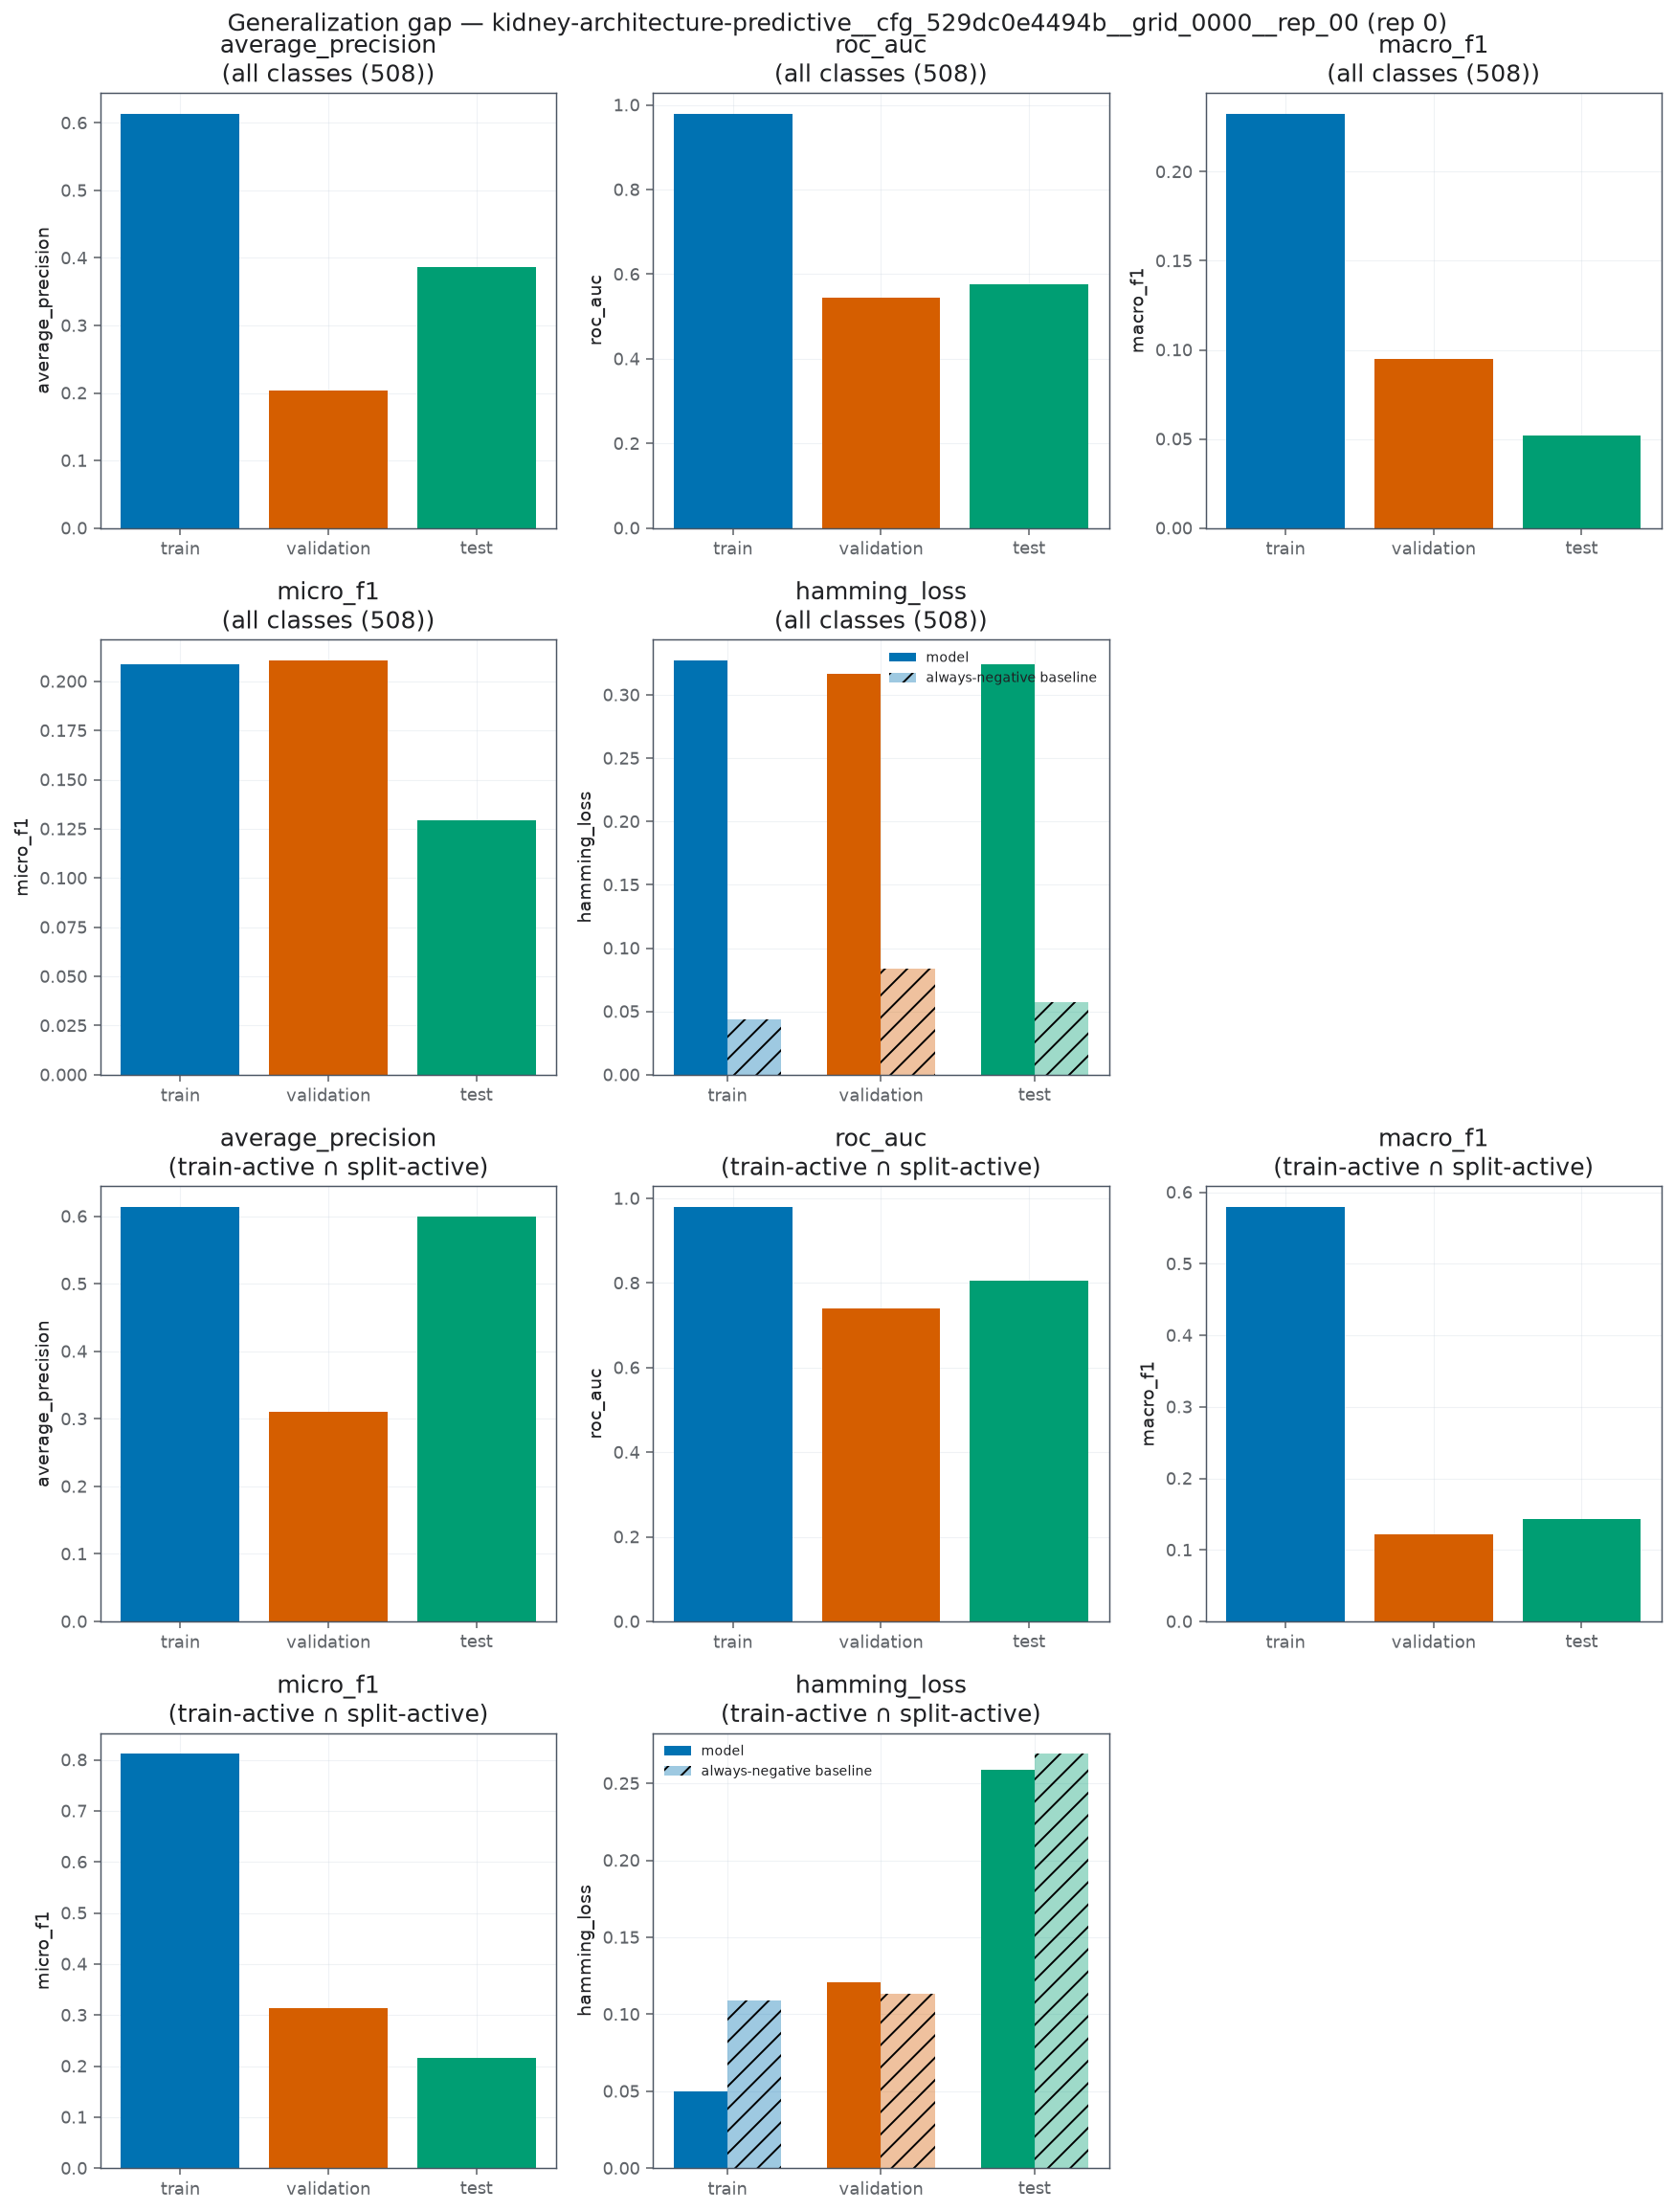

In [9]:
import matplotlib.pyplot as plt

split_order = ["train", "validation", "test"]
# Same grouping as the table above: ranking + macro on top (the metrics this
# notebook actually trusts), micro + calibration below (shown for context, per the
# "trap" discussion, not as primary evidence). Repeated once per scope -- full 508
# classes, then train-active-only -- stacked vertically so the two are directly
# comparable panel by panel.
panel_layout = [
    ["average_precision", "roc_auc", "macro_f1"],
    ["micro_f1", "hamming_loss"],
]
scope_names = [ALL_CLASSES_SCOPE, TRAIN_ACTIVE_SCOPE]
rows_per_scope = len(panel_layout)
total_rows = rows_per_scope * len(scope_names)

figure, axes = plt.subplots(total_rows, 3, figsize=(12.6, 4.2 * total_rows), dpi=theme.figure_dpi)
bar_width = 0.35
for scope_index, scope_name in enumerate(scope_names):
    for row, metric_row in enumerate(panel_layout):
        axis_row = scope_index * rows_per_scope + row
        for column, metric_name in enumerate(metric_row):
            axis = axes[axis_row, column]
            x_positions = np.arange(len(split_order))
            values = [gap_by_split_scope.loc[(split_name, scope_name), metric_name] for split_name in split_order]
            if metric_name == "hamming_loss":
                # An always-negative predictor's hamming_loss equals exactly the positive
                # rate -- shown alongside the real value so a bare number is never read in
                # isolation (a model can sit above the baseline purely from over-predicting,
                # not from being a bad classifier).
                baseline_values = [
                    gap_by_split_scope.loc[(split_name, scope_name), "hamming_loss_baseline_positive_rate"]
                    for split_name in split_order
                ]
                axis.bar(x_positions - bar_width / 2, values, width=bar_width, label="model",
                         color=[theme.color_for_model(split_name, index) for index, split_name in enumerate(split_order)])
                axis.bar(x_positions + bar_width / 2, baseline_values, width=bar_width, label="always-negative baseline",
                         color=[theme.color_for_model(split_name, index) for index, split_name in enumerate(split_order)],
                         alpha=theme.overlapping_signal_alpha, hatch="//")
                axis.legend(fontsize=7, frameon=theme.legend_frame)
            else:
                axis.bar(x_positions, values, color=[theme.color_for_model(split_name, index) for index, split_name in enumerate(split_order)])
            axis.set_xticks(x_positions)
            axis.set_xticklabels(split_order)
            axis.set(ylabel=metric_name, title=f"{metric_name}\n({scope_name})")
            axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
        for column in range(len(metric_row), 3):
            axes[axis_row, column].axis("off")
figure.suptitle(f"Generalization gap — {MODEL_NAMES[0]} (rep 0)", fontsize=13)
figure.tight_layout()

#### `hamming_loss` vs. its always-negative baseline, split by split (all-classes scope)

| split | model `hamming_loss` | baseline (always-negative) | model / baseline |
|---|---|---|---|
| `train` | 0.327 | 0.044 | **7.50x** |
| `validation` | 0.316 | 0.084 | **3.78x** |
| `test` | 0.324 | 0.057 | **5.64x** |

- The model is worse than predicting nothing everywhere, by 3.8x to 7.5x depending on
  split — consistent with the calibration finding elsewhere in this project (`bce+
  pos_weight` predicts positive for ~31% of cells at threshold 0.5 against a ~5-8%
  true rate): correcting for class imbalance via `pos_weight` makes the model catch
  real positives, but at threshold 0.5 it over-predicts heavily enough to lose to the
  trivial baseline on this specific metric. This is expected, not a sign the model is
  bad — see rule 1 in this campaign's methodology: threshold 0.5 measures calibration,
  not discrimination, and `pos_weight` was never tuned to make 0.5 a calibrated cutoff.
- **`validation`'s baseline (0.084) is nearly double `train`'s (0.044) and clearly
  above `test`'s (0.057)** — this is the same class-composition difference documented
  below (`validation` has 319 nonzero classes to `train`'s 204, and 82% of its
  positive labels sit on classes `train` never saw): a `dataset_id`-grouped split
  that draws `validation` disproportionately from tissue regions carrying different,
  often more prevalent, molecule annotations. The model/baseline ratio being *smaller*
  on `validation` (3.78x) than `train`/`test` is a direct consequence of this larger
  baseline, not evidence the model does anything differently there.
- **The most informative thing about this table is what does *not* change**: model
  `hamming_loss` sits at 0.316-0.327 across all three splits — a ~3% relative range —
  while `macro_f1` collapses by ~4.5x from `train` (0.233) to `test` (0.052) over the
  same three splits (all-classes scope; see the chart above). `hamming_loss` is
  essentially blind to the real generalization gap this notebook is trying to detect,
  because it is dominated by the model's fairly constant over-prediction behavior at
  threshold 0.5, not by whether the model is actually right about *which* pixels are
  positive. This is the concrete version of why `average_precision`, not
  `hamming_loss`, is the metric this notebook trusts.


#### Why `validation`'s AUPRC looks lower than `test`'s, despite `macro_f1` decreasing monotonically

`validation` AUPRC (0.204, all-classes) is *lower* than `test` AUPRC (0.386),
despite `macro_f1` decreasing monotonically train→validation→test as expected. This
is not evidence the model generalizes worse to validation than to test — it is a
split composition artifact, confirmed directly against the ground-truth annotations
(independent of any model):

| | classes w/ any positive | overlap with `train`'s classes | positives on train-unseen classes |
|---|---|---|---|
| `train` | 204 / 508 | — | — |
| `validation` | 319 / 508 | 68 (21%) | 156,107 / 190,604 (**82%**) |
| `test` | 113 / 508 | 31 (27%) | 83,716 / 117,294 (**71%**) |

`validation` actually has *more* distinct annotated classes present than `train` does,
despite `train` having 7.5x more pixels — and 82% of every positive label in
`validation` belongs to a molecule class the model has **zero** positive training
examples for (some at up to ~2000/4488 ≈ 45% prevalence *within* `validation` alone,
per-class). The model cannot have learned anything about a class it never saw a single
positive example of; scoring it there is closer to measuring zero-shot generalization
to unseen classes than measuring overfitting. `test` has the same problem at a smaller
scale (71% of its positives are on train-unseen classes), which is the more likely
explanation for `test`'s own AUPRC being well below `train`'s, on top of ordinary
overfitting.

This is exactly the "grupowy split" (group-structured, not per-pixel-random split)
concern raised earlier in this project's methodology discussion — confirmed here as a
real, measurable effect, not a hypothetical one. Any AUPRC comparison against
`validation` specifically should be read with this in mind; `test` is the split this
notebook's other sections already treat as primary for exactly this reason.


## The trap, made explicit: an all-zero predictor vs. the trained model

### Methodology
#### Theoretical
- A model that predicts **all zeros** would still score a deceptively high
  micro-accuracy/precision/hamming-loss on most classes, simply because "absent" is
  the overwhelming majority label everywhere. This section makes that trap explicit
  by computing the same metrics for an actual all-zero baseline and comparing them
  side by side against the trained model, in both the all-classes and fair
  (`train-active ∩ test-active`) scopes, across all 5 repetitions.

#### Implementation
- `zero_baseline_logits` feeds a constant, strongly-negative logit (every predicted
  probability ≈ 0, so nothing crosses the 0.5 threshold) through the exact same
  `evaluate_head` used for the trained model — same metric functions, same test
  split, same mask, same two class scopes. `hamming_loss` and
  `micro_precision`/`micro_recall` collapse toward the always-negative class's
  dominance for the baseline; `average_precision`/`roc_auc` do not, since each
  class's baseline is its own prevalence (average_precision) or its own
  positive/negative ranking (roc_auc) rather than the global (dominated-by-zero)
  label balance — this is exactly why these are the headline metrics to trust here,
  not accuracy-shaped ones. Aggregated via `groupby("predictor")[...].agg(["mean",
  "std"])` across the 5 repetitions, once per scope.

### Notes
- **All 508 classes** (mean ± std across 5 reps): trained model average_precision
  0.364±0.02 vs. baseline 0.258 (roc_auc 0.565±0.02 vs. 0.500) — a real but modest
  separation from the trivial baseline once every unlearnable/absent class dilutes
  the average.
- **Fair scope (`train-active ∩ test-active`, 31/508 classes)**: trained model
  average_precision 0.512±0.01 vs. baseline 0.269 (roc_auc 0.740±0.06 vs. 0.500) — a
  much larger, clearer separation from chance once scored only on classes the model
  had any chance to learn and that are actually present in this split. This is the
  scope that should be trusted when the question is "can this model do anything at
  all," not the all-508 pool.
- `hamming_loss`/`micro_precision`/`micro_recall` still show the baseline "winning"
  on `hamming_loss` in both scopes (all-zero's hamming_loss equals its own
  `hamming_loss_baseline_positive_rate` by construction) — the exact trap this
  section exists to make explicit; see the generalization-gap section above for the
  full argument on why `hamming_loss` should not be read as a quality signal here.


In [10]:
def zero_baseline_logits(shape: tuple[int, int]) -> np.ndarray:
    return np.full(shape, -30.0, dtype=np.float32)  # sigmoid(-30) ~ 9e-14, avoids exp() overflow warning


test_positive_count_per_class = (results[MODEL_NAMES[0]]["targets"] * results[MODEL_NAMES[0]]["mask"]).sum(axis=0)
test_active_class_mask = test_positive_count_per_class > 0
test_fair_mask = train_active_class_mask & test_active_class_mask
print(
    f"train-active ∩ test-active: {int(test_fair_mask.sum())}/{test_fair_mask.shape[0]} classes are both "
    "learnable and have test ground truth to score against"
)

baseline_rows = []
model_rows = []
for model_name, result in results.items():
    for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (TRAIN_ACTIVE_SCOPE, test_fair_mask)):
        scoped_logits = result["logits"][:, class_selector]
        scoped_targets = result["targets"][:, class_selector]
        scoped_mask = result["mask"][:, class_selector]
        baseline_metrics = evaluate_head(
            zero_baseline_logits(scoped_logits.shape), scoped_targets, "multi_label", scoped_mask, THRESHOLD
        )
        model_metrics = evaluate_head(scoped_logits, scoped_targets, "multi_label", scoped_mask, THRESHOLD)
        baseline_rows.append({"model_name": model_name, "scope": scope_name, **baseline_metrics})
        model_rows.append({"model_name": model_name, "scope": scope_name, **model_metrics})

comparison = pd.concat(
    [
        pd.DataFrame(baseline_rows).assign(predictor="all-zero baseline"),
        pd.DataFrame(model_rows).assign(predictor="trained model"),
    ],
    ignore_index=True,
).set_index(["predictor", "scope", "model_name"])
comparison

train-active ∩ test-active: 31/508 classes are both learnable and have test ground truth to score against


micro_f1  \
predictor         scope                       model_name                                                     
all-zero baseline all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
trained model     all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.129376   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.216229   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.115802   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.186879   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.112518   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.186255   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.124834   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.250803   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.107734   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.182973   

                                                                                                  macro_f1  \
predictor         scope                       model_name                                                     
all-zero baseline all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.000000   
trained model     all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.051750   
                  train-active ∩ split-active kidney-architecture-predictive__cfg_529dc0e4494...  0.143593   
                  all classes (508)           kidney-architecture-predictive__cfg_529dc0e4494...  0.047010   
                  train-act

**All 508 classes:**

In [11]:
comparison.xs(ALL_CLASSES_SCOPE, level="scope").groupby("predictor")[
    ["micro_f1", "macro_f1", "micro_precision", "micro_recall", "hamming_loss", "hamming_loss_baseline_positive_rate", "average_precision", "roc_auc"]
].agg(["mean", "std"])

micro_f1            macro_f1          micro_precision  \
                       mean       std      mean      std            mean   
predictor                                                                  
all-zero baseline  0.000000  0.000000  0.000000  0.00000        0.000000   
trained model      0.118053  0.008894  0.047808  0.00413        0.069796   

                            micro_recall           hamming_loss            \
                        std         mean       std         mean       std   
predictor                                                                   
all-zero baseline  0.000000     0.000000  0.000000     0.057393  0.000000   
trained model      0.005349     0.382828  0.028013     0.328477  0.011244   

                  hamming_loss_baseline_positive_rate      average_precision  \
                                                 mean  std              mean   
predictor                                                                      
all-zero baseline                            0.057393  0.0          0.258016   
trained model                                0.057393  0.0          0.364260   

                              roc_auc            
                        std      mean       std  
predictor                                        
all-zero baseline  0.000000  0.500000  0.000000  
trained model      0.016666  0.565003  0.021311

**Train-active ∩ test-active only (the fair comparison):**

In [12]:
comparison.xs(TRAIN_ACTIVE_SCOPE, level="scope").groupby("predictor")[
    ["micro_f1", "macro_f1", "micro_precision", "micro_recall", "hamming_loss", "hamming_loss_baseline_positive_rate", "average_precision", "roc_auc"]
].agg(["mean", "std"])

micro_f1            macro_f1           micro_precision  \
                       mean       std      mean       std            mean   
predictor                                                                   
all-zero baseline  0.000000  0.000000  0.000000  0.000000        0.000000   
trained model      0.204628  0.029104  0.141823  0.014119        0.524878   

                            micro_recall          hamming_loss            \
                        std         mean      std         mean       std   
predictor                                                                  
all-zero baseline  0.000000     0.000000  0.00000     0.269242  0.000000   
trained model      0.045358     0.127607  0.02201     0.266110  0.005854   

                  hamming_loss_baseline_positive_rate      average_precision  \
                                                 mean  std              mean   
predictor                                                                      
all-zero baseline                            0.269242  0.0          0.269242   
trained model                                0.269242  0.0          0.511740   

                              roc_auc            
                        std      mean       std  
predictor                                        
all-zero baseline  0.000000  0.500000  0.000000  
trained model      0.065603  0.739891  0.063238

## Per-class detail — worst and best classes by AUPRC (`grid_0000`, rep 0)

### Methodology
#### Theoretical
- Aggregate metrics (macro_f1, average_precision) hide which specific classes drive
  the number. Looking at the best/worst-scoring individual classes gives a concrete,
  checkable sense of what "the model does well/poorly" actually means at the class
  level, beyond a single averaged statistic.

#### Implementation
- Uses `reference_class_metrics` (`per_class_metrics` on rep 0, test split), filtered
  to `positive_samples > 0` and sorted by `average_precision`. Classes with zero test
  positives are excluded here (`average_precision_score` is undefined for a class
  with no positive examples in the evaluated set — sklearn returns `nan`/raises a
  warning for it, not a meaningful zero); their count is already reported in the
  class-sparsity section above, and they are, definitionally, pure false-positive
  risk for this model.

### Notes


In [13]:
scored_classes = reference_class_metrics[reference_class_metrics["positive_samples"] > 0].copy()
scored_classes = scored_classes.sort_values("average_precision")
print(f"{len(scored_classes)}/{class_count} classes had ≥1 test positive and could be scored")

print("=== worst 10 by AUPRC ===")
display_cols = ["class_index", "positive_samples", "precision", "recall", "f1", "average_precision"]
scored_classes[display_cols].head(10)


113/508 classes had ≥1 test positive and could be scored
=== worst 10 by AUPRC ===


,class_index,positive_samples,precision,recall,f1,average_precision
179,179.0,2.0,0.000000,0.000000,0.000000,0.000452
283,283.0,10.0,0.000000,0.000000,0.000000,0.002028
304,304.0,24.0,0.003982,0.583333,0.007910,0.003658
89,89.0,35.0,0.000000,0.000000,0.000000,0.007795
305,305.0,12.0,0.000000,0.000000,0.000000,0.007822
169,169.0,9.0,0.005556,1.000000,0.011050,0.007856
485,485.0,3.0,0.000947,1.000000,0.001892,0.008064
139,139.0,89.0,0.019509,0.741573,0.038018,0.014550
264,264.0,87.0,0.000000,0.000000,0.000000,0.014685
141,141.0,56.0,0.000000,0.000000,0.000000,0.023316


In [14]:
print("=== best 10 by AUPRC ===")
scored_classes[display_cols].tail(10).sort_values("average_precision", ascending=False)


=== best 10 by AUPRC ===


,class_index,positive_samples,precision,recall,f1,average_precision
135,135.0,2099.0,1.000000,0.006193,0.012311,0.999912
142,142.0,1860.0,0.966396,0.896774,0.930284,0.975358
130,130.0,1958.0,1.000000,0.356997,0.526157,0.972579
214,214.0,1371.0,0.000000,0.000000,0.000000,0.971267
173,173.0,1427.0,0.000000,0.000000,0.000000,0.969450
288,288.0,927.0,0.647687,0.981661,0.780446,0.964802
124,124.0,1714.0,0.000000,0.000000,0.000000,0.955439
372,372.0,1292.0,0.000000,0.000000,0.000000,0.949943
149,149.0,1710.0,0.784672,0.880117,0.829658,0.948591
394,394.0,1484.0,0.000000,0.000000,0.000000,0.944013


## Repetition variance

### Methodology
#### Theoretical
- A single repetition's numbers could be a lucky or unlucky draw from seed noise
  alone. Comparing across all 5 shared-seed repetitions of `grid_0000` shows whether
  this notebook's headline read (e.g. rep 0's fair-scope average_precision) is
  representative or would have looked meaningfully different under a different seed.

#### Implementation
- Same `average_precision`/`macro_f1`/`roc_auc`/`hamming_loss` columns as the
  trap-comparison table above, indexed by `(scope, model_name)` for the `trained
  model` predictor row only — i.e. the 5 individual repetitions, not their mean, in
  both the all-classes and fair scopes.

### Notes


In [15]:
comparison.loc["trained model"][["macro_f1", "average_precision", "roc_auc", "hamming_loss", "hamming_loss_baseline_positive_rate"]]

,,macro_f1,average_precision,roc_auc,hamming_loss,hamming_loss_baseline_positive_rate
scope,model_name,,,,,
all classes (508),kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00,0.051750,0.385860,0.576276,0.323778,0.057393
train-active ∩ split-active,kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_00,0.143593,0.599645,0.805667,0.258674,0.269242
all classes (508),kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_01,0.047010,0.377192,0.582973,0.322785,0.057393
train-active ∩ split-active,kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_01,0.128267,0.517983,0.768768,0.274783,0.269242
all classes (508),kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_02,0.043477,0.345492,0.532637,0.320944,0.057393
train-active ∩ split-active,kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_02,0.138897,0.436992,0.643885,0.266035,0.269242
all classes (508),kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_03,0.052439,0.357008,0.579100,0.326627,0.057393
train-active ∩ split-active,kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_03,0.164891,0.459183,0.712127,0.263814,0.269242
all classes (508),kidney-architecture-predictive__cfg_529dc0e4494b__grid_0000__rep_04,0.044366,0.355747,0.554029,0.348251,0.057393


## Notes for the next pass

Facts established here, not yet interpreted:

- `average_precision` (macro AUPRC) is the metric to lead with for this head — it is
  the one in the comparison table above that actually separates the trained model from
  the all-zero baseline; the accuracy-shaped metrics (`hamming_loss`,
  `micro_precision`) do not, exactly as the introduction warned.
- A large fraction of the 508 classes have zero positive pixels on this particular
  4023-pixel test split (see the sparsity histogram) — those are excluded from the
  per-class AUPRC ranking above since the metric is undefined for them, not because
  they are unimportant; every predicted positive on one of them is definitionally a
  false positive for this evaluation.
- Not yet done: the same evaluation for the other six `objectives` ablations (this
  notebook only reused `grid_0000`'s `describe_objective` label as a filename
  suffix — extending `MODEL_NAMES` to another `grid_000N` and re-running reproduces
  this whole notebook for it), and per-class spatial maps (`../report/methodology.md`
  mentions counterfactual peak-ablation as a stronger causal test than these
  classification metrics alone — a later, separate analysis).
- The environment workaround above (`SCRATCH_WORKSPACE_ROOT` symlink) is local to this
  machine's `/tmp`; a fresh environment needs it recreated before this notebook (or any
  notebook loading a predictive-campaign model through `wrapper.load_configuration`)
  will run.
